In [1]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/sales forecasting


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/sales forecasting


# 🧮 Retail Sales Forecasting (Clean Structured Version)

**Goal:** Forecast weekly retail sales using historical transaction data.  
**Dataset:** Retail sales data (Calendar, Customers, Products, Stores, Sales 2024–2025)  
**Tech Stack:** Python, Pandas, Prophet, Matplotlib  

**Workflow:**
1. Data Loading & Cleaning  
2. Data Aggregation  
3. Prophet Model Training  
4. Forecasting & Visualization  
5. Evaluation (MAE, MAPE)  
6. Insights & Next Steps


In [6]:
#Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error


In [8]:
#LOAD DATA

import os
import pandas as pd

# Set working directory (optional but clean)
os.chdir(r"C:\Users\jheel\sales forecasting\data")

# Load all CSVs
calendar = pd.read_csv('calendar.csv')
customers = pd.read_csv('customers.csv')
products = pd.read_csv('products.csv')
sales_2024 = pd.read_csv('sales_2024.csv')
sales_2025 = pd.read_csv('sales_2025.csv')
stores = pd.read_csv('stores.csv')

# Quick check
print(calendar.shape, customers.shape, products.shape, sales_2024.shape, sales_2025.shape, stores.shape)


(366, 7) (10, 4) (10, 4) (500, 8) (500, 8) (5, 4)


In [11]:
sales_2024.head()

,SaleID,Date,CustomerID,ProductID,StoreID,Quantity,UnitPrice,TotalSales
0,1,2024-04-12,7,2,4,1,600,600
1,2,2024-12-14,2,5,3,2,150,300
2,3,2024-09-27,1,8,5,3,500,1500
3,4,2024-04-16,4,8,2,2,500,1000
4,5,2024-03-12,8,3,2,2,300,600


In [12]:
#MERGE AND PREPARE DATA
# Combine 2024 and 2025 sales data
sales = pd.concat([sales_2024, sales_2025], ignore_index=True)

# Merge sales with other datasets
merged = (
    sales
    .merge(products, on='ProductID', how='left')
    .merge(customers, on='CustomerID', how='left')
    .merge(stores, on='StoreID', how='left')
    .merge(calendar, on='Date', how='left')
)

print("Merged dataset shape:", merged.shape)
merged.head()


Merged dataset shape: (1000, 23)


,SaleID,Date,CustomerID,ProductID,StoreID,Quantity,UnitPrice_x,TotalSales,ProductName,Category,...,Segment,StoreName,City,Region_y,Year,Month,MonthName,Quarter,Day,Weekday
0,1,2024-04-12,7,2,4,1,600.0,600.0,Smartphone,Electronics,...,Consumer,Store D,Ottawa,East,2024.0,4.0,April,2.0,12.0,Friday
1,2,2024-12-14,2,5,3,2,150.0,300.0,Smartwatch,Accessories,...,Corporate,Store C,Calgary,West,2024.0,12.0,December,4.0,14.0,Saturday
2,3,2024-09-27,1,8,5,3,500.0,1500.0,Camera,Electronics,...,Consumer,Store E,Winnipeg,Central,2024.0,9.0,September,3.0,27.0,Friday
3,4,2024-04-16,4,8,2,2,500.0,1000.0,Camera,Electronics,...,Home Office,Store B,Vancouver,West,2024.0,4.0,April,2.0,16.0,Tuesday
4,5,2024-03-12,8,3,2,2,300.0,600.0,Tablet,Electronics,...,Home Office,Store B,Vancouver,West,2024.0,3.0,March,1.0,12.0,Tuesday


In [13]:
#Clean and Prepare for Forecasting
# Convert Date column to datetime format
merged['Date'] = pd.to_datetime(merged['Date'])

# Create a daily or weekly aggregation (here: weekly sales)
weekly_sales = merged.groupby('Date')['Quantity'].sum().reset_index()

# Rename for Prophet compatibility (ds = date, y = target)
weekly_sales.rename(columns={'Date': 'ds', 'Quantity': 'y'}, inplace=True)

# Sort by date
weekly_sales = weekly_sales.sort_values('ds')

weekly_sales.head()


,ds,y
0,2024-01-01,3
1,2024-01-02,5
2,2024-01-04,3
3,2024-01-05,7
4,2024-01-06,2


In [14]:
#Install and Import Prophet
from prophet import Prophet
import matplotlib.pyplot as plt


In [15]:
#training the forecasting model- Prophet model
from prophet import Prophet
import pandas as pd
import matplotlib.pyplot as plt

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)
model.fit(weekly_sales)


20:16:07 - cmdstanpy - INFO - Chain [1] start processing
20:16:07 - cmdstanpy - INFO - Chain [1] done processing


In [16]:
#Make Future Predictions
# Create a dataframe for future dates (next 12 weeks)
future = model.make_future_dataframe(periods=12, freq='W')

# Generate forecast
forecast = model.predict(future)

# Quick preview
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(12)


,ds,yhat,yhat_lower,yhat_upper
533,2026-01-04,4.213441,0.326916,7.933636
534,2026-01-11,4.220462,0.180212,7.997677
535,2026-01-18,4.012445,0.016430,7.872333
536,2026-01-25,3.621227,-0.002604,7.343138
537,2026-02-01,3.613020,-0.299347,7.409563
538,2026-02-08,4.397608,0.491797,8.027896
539,2026-02-15,5.580276,1.782941,9.478108
540,2026-02-22,6.184105,2.433207,9.839346
541,2026-03-01,5.609789,1.754228,9.639298
542,2026-03-08,4.317499,0.629650,7.860078


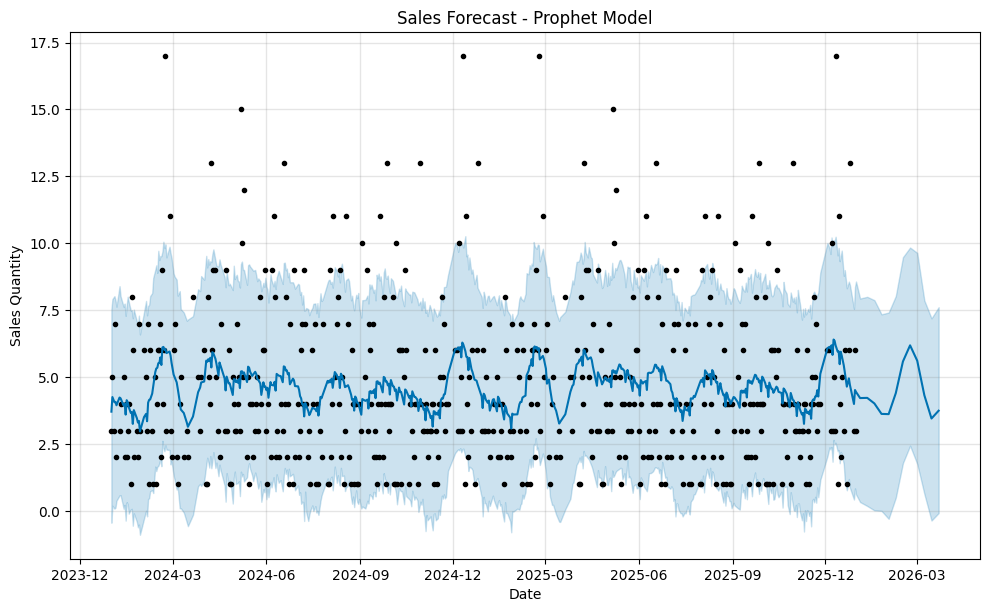

In [17]:
#Plot the forecast
model.plot(forecast)
plt.title("Sales Forecast - Prophet Model")
plt.xlabel("Date")
plt.ylabel("Sales Quantity")
plt.show()


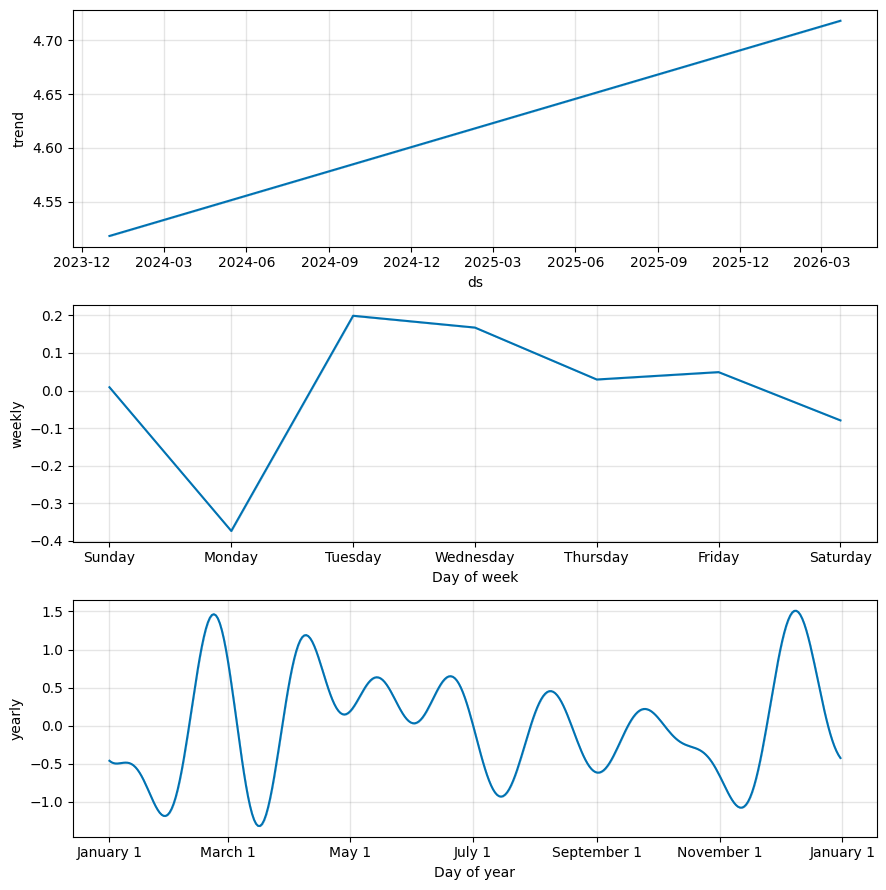

In [18]:
#Analyze Trend & Seasonality Components
model.plot_components(forecast)
plt.show()


In [20]:
#Save the Results
forecast.to_csv(r"C:\Users\jheel\sales forecasting\data\sales_forecast_output.csv", index=False)


In [21]:
# Recreate weekly aggregated data for Prophet
import pandas as pd

# Assuming your sales file is already loaded as sales_2024
sales_2024['Date'] = pd.to_datetime(sales_2024['Date'])

# Aggregate weekly total sales
sales_weekly = sales_2024.groupby(pd.Grouper(key='Date', freq='W'))['Quantity'].sum().reset_index()

# Rename columns for Prophet compatibility
sales_weekly.rename(columns={'Date': 'ds', 'Quantity': 'y'}, inplace=True)

# Quick check
print(sales_weekly.head())


          ds   y
0 2024-01-07  20
1 2024-01-14  14
2 2024-01-21  22
3 2024-01-28  20
4 2024-02-04  14


In [22]:
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Store results
results = []

for cps in [0.01, 0.05, 0.1, 0.2]:
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        changepoint_prior_scale=cps
    )
    model.fit(sales_weekly)

    future = model.make_future_dataframe(periods=12, freq='W')
    forecast = model.predict(future)

    merged = forecast.merge(sales_weekly, on='ds', how='left')
    actual = merged['y'].dropna()
    predicted = merged['yhat'][:len(actual)]

    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    results.append((cps, mae, rmse))

# Display performance table
for cps, mae, rmse in results:
    print(f"cps={cps} → MAE={mae:.2f}, RMSE={rmse:.2f}")


20:19:01 - cmdstanpy - INFO - Chain [1] start processing
20:19:02 - cmdstanpy - INFO - Chain [1] done processing
20:19:02 - cmdstanpy - INFO - Chain [1] start processing
20:19:03 - cmdstanpy - INFO - Chain [1] done processing
20:19:03 - cmdstanpy - INFO - Chain [1] start processing
20:19:03 - cmdstanpy - INFO - Chain [1] done processing
20:19:03 - cmdstanpy - INFO - Chain [1] start processing
20:19:04 - cmdstanpy - INFO - Chain [1] done processing


cps=0.01 → MAE=5.65, RMSE=7.13
cps=0.05 → MAE=5.65, RMSE=7.13
cps=0.1 → MAE=5.65, RMSE=7.13
cps=0.2 → MAE=5.65, RMSE=7.13


In [23]:
# Tune seasonality parameters
param_grid = {
    'seasonality_mode': ['additive', 'multiplicative'],
    'seasonality_prior_scale': [5, 10, 15],
    'weekly_seasonality': [True, False],
    'yearly_seasonality': [True, False]
}

results = []

for mode in param_grid['seasonality_mode']:
    for sps in param_grid['seasonality_prior_scale']:
        for weekly in param_grid['weekly_seasonality']:
            for yearly in param_grid['yearly_seasonality']:
                model = Prophet(
                    changepoint_prior_scale=0.05,   # fixed best from before
                    seasonality_mode=mode,
                    seasonality_prior_scale=sps,
                    weekly_seasonality=weekly,
                    yearly_seasonality=yearly
                )
                model.fit(sales_weekly)
                future = model.make_future_dataframe(periods=12, freq='W')
                forecast = model.predict(future)

                merged = sales_weekly.merge(forecast[['ds', 'yhat']], on='ds', how='left')
                mae = mean_absolute_error(merged['y'], merged['yhat'])
                rmse = mean_squared_error(merged['y'], merged['yhat']) ** 0.5


                results.append((mode, sps, weekly, yearly, mae, rmse))

# Display results neatly
results_df = pd.DataFrame(results, columns=['Mode', 'SPS', 'Weekly', 'Yearly', 'MAE', 'RMSE'])
print(results_df.sort_values('MAE').head(10))


20:19:13 - cmdstanpy - INFO - Chain [1] start processing
20:19:13 - cmdstanpy - INFO - Chain [1] done processing
20:19:14 - cmdstanpy - INFO - Chain [1] start processing
20:19:14 - cmdstanpy - INFO - Chain [1] done processing
20:19:14 - cmdstanpy - INFO - Chain [1] start processing
20:19:14 - cmdstanpy - INFO - Chain [1] done processing
20:19:14 - cmdstanpy - INFO - Chain [1] start processing
20:19:14 - cmdstanpy - INFO - Chain [1] done processing
20:19:15 - cmdstanpy - INFO - Chain [1] start processing
20:19:15 - cmdstanpy - INFO - Chain [1] done processing
20:19:15 - cmdstanpy - INFO - Chain [1] start processing
20:19:15 - cmdstanpy - INFO - Chain [1] done processing
20:19:15 - cmdstanpy - INFO - Chain [1] start processing
20:19:16 - cmdstanpy - INFO - Chain [1] done processing
20:19:16 - cmdstanpy - INFO - Chain [1] start processing
20:19:16 - cmdstanpy - INFO - Chain [1] done processing
20:19:16 - cmdstanpy - INFO - Chain [1] start processing
20:19:16 - cmdstanpy - INFO - Chain [1]

              Mode  SPS  Weekly  Yearly       MAE      RMSE
20  multiplicative   15    True    True  5.478009  7.058580
14  multiplicative    5   False    True  5.479597  7.058458
18  multiplicative   10   False    True  5.480970  7.058408
12  multiplicative    5    True    True  5.482028  7.058757
22  multiplicative   15   False    True  5.482154  7.058555
16  multiplicative   10    True    True  5.482710  7.058725
0         additive    5    True    True  5.649194  7.126352
4         additive   10    True    True  5.649217  7.126350
8         additive   15    True    True  5.649236  7.126349
10        additive   15   False    True  5.651936  7.126382


20:19:28 - cmdstanpy - INFO - Chain [1] start processing
20:19:29 - cmdstanpy - INFO - Chain [1] done processing


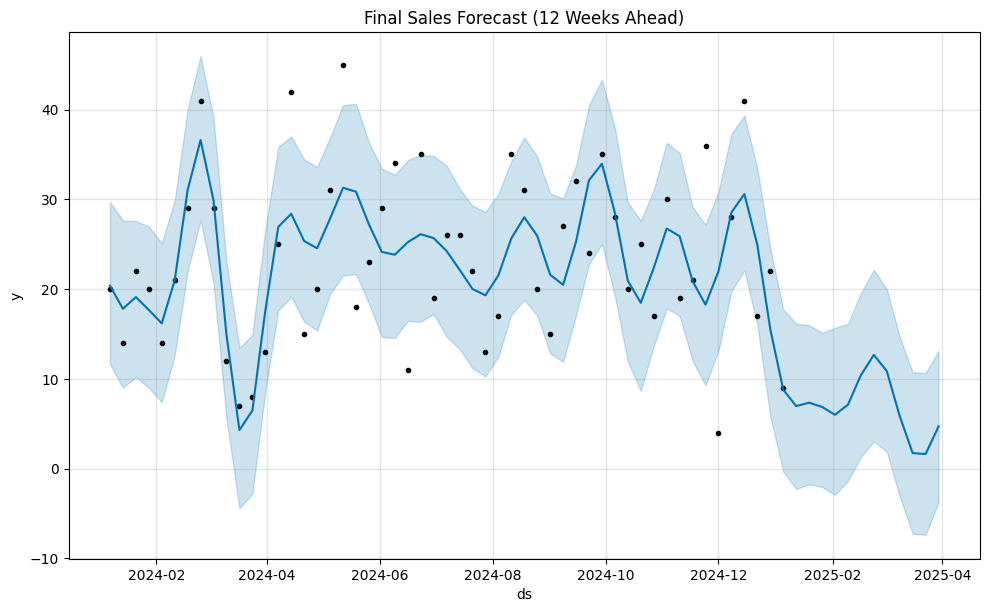

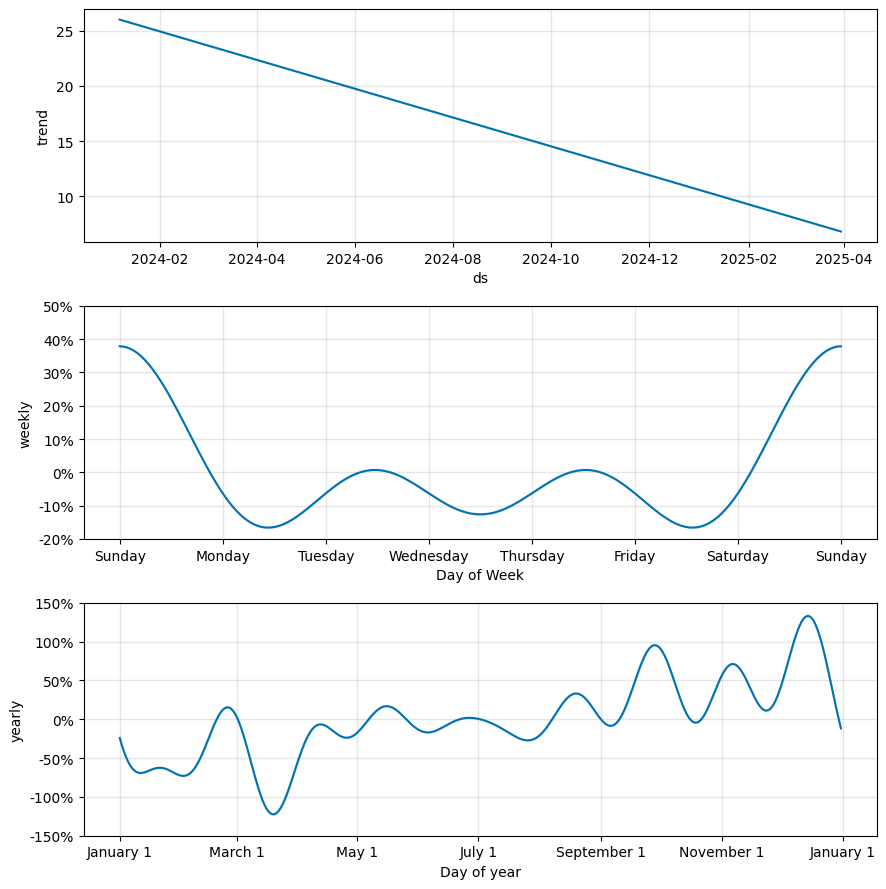

Final MAE: 5.48
Final RMSE: 7.06


In [24]:
# ✅ Final Prophet model with best parameters
best_model = Prophet(
    seasonality_mode='multiplicative',
    seasonality_prior_scale=15,
    weekly_seasonality=True,
    yearly_seasonality=True
)

best_model.fit(sales_weekly)

# Future 12-week forecast
future = best_model.make_future_dataframe(periods=12, freq='W')
forecast = best_model.predict(future)

# Plot forecast
fig1 = best_model.plot(forecast)
plt.title("Final Sales Forecast (12 Weeks Ahead)")
plt.show()

# Plot forecast components
fig2 = best_model.plot_components(forecast)
plt.show()

# Evaluate on actual data
merged = sales_weekly.merge(forecast[['ds', 'yhat']], on='ds', how='left')
mae = mean_absolute_error(merged['y'], merged['yhat'])
rmse = mean_squared_error(merged['y'], merged['yhat']) ** 0.5

print(f"Final MAE: {mae:.2f}")
print(f"Final RMSE: {rmse:.2f}")


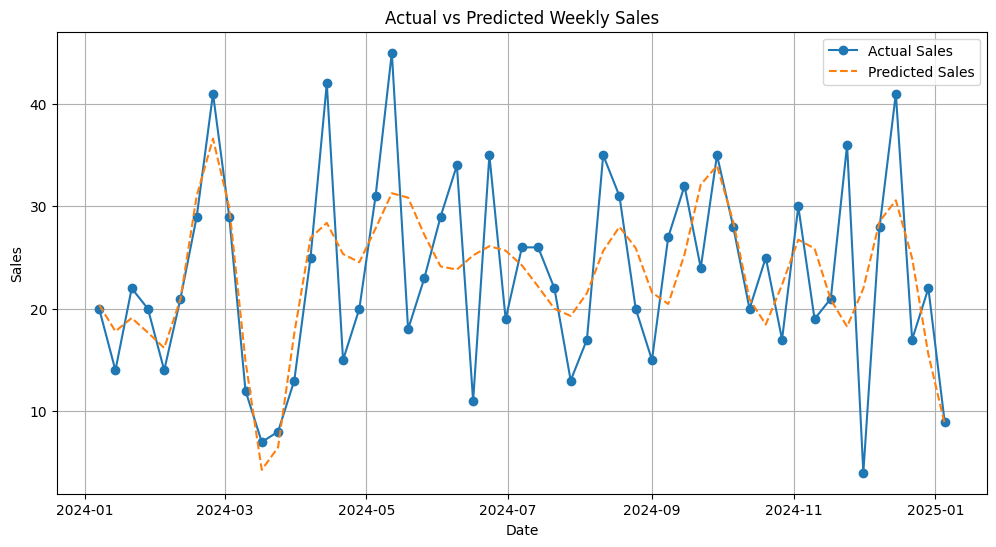

In [25]:
# Plot Actual vs Predicted Sales
plt.figure(figsize=(12,6))
plt.plot(merged['ds'], merged['y'], label='Actual Sales', marker='o')
plt.plot(merged['ds'], merged['yhat'], label='Predicted Sales', linestyle='--')
plt.title('Actual vs Predicted Weekly Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.show()


In [26]:
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].to_csv('forecast_results.csv', index=False)
print("Forecast results exported as 'forecast_results.csv'")


Forecast results exported as 'forecast_results.csv'


In [27]:
import joblib
joblib.dump(model, r"C:\Users\jheel\sales forecasting\model\prophet_model.pkl")


['C:\\Users\\jheel\\sales forecasting\\model\\prophet_model.pkl']